In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [6]:
print("Loading MNIST dataset...")

mnist = fetch_openml('mnist_784', version=1)

X = mnist.data.values
y = mnist.target.astype(int).values.reshape(-1,1)

# Normalize pixel values (0-255 → 0-1)
X = X / 255.0

print("Dataset shape:", X.shape)

Loading MNIST dataset...
Dataset shape: (70000, 784)


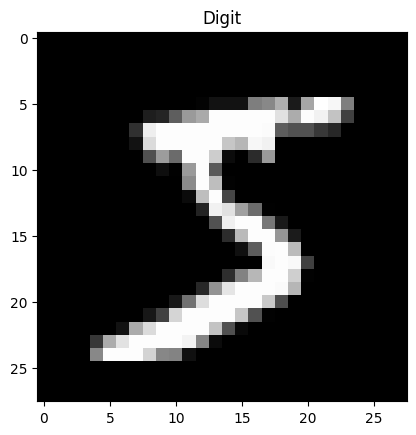

In [7]:
plt.imshow(X[0].reshape(28,28), cmap="gray")
plt.title("Digit")
plt.show()

In [8]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (56000, 784)
Testing samples: (14000, 784)


In [10]:
print(y_train.shape)
print(y_train[:5])

(56000, 10)
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]]


In [11]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

In [12]:
input_size = 784
hidden1 = 256
hidden2 = 128
output_size = 10

np.random.seed(42)

W1 = np.random.randn(input_size, hidden1) * np.sqrt(2/input_size)
b1 = np.zeros((1, hidden1))

W2 = np.random.randn(hidden1, hidden2) * np.sqrt(2/hidden1)
b2 = np.zeros((1, hidden2))

W3 = np.random.randn(hidden2, output_size) * np.sqrt(2/hidden2)
b3 = np.zeros((1, output_size))

In [13]:
perm = np.random.permutation(X_train.shape[0])
X_train = X_train[perm]
y_train = y_train[perm]

In [14]:
learning_rate = 0.003
epochs = 40
batch_size = 128
m = X_train.shape[0]

for epoch in range(epochs):

    permutation = np.random.permutation(m)
    X_train_shuffled = X_train[permutation]
    y_train_shuffled = y_train[permutation]

    for i in range(0, m, batch_size):

        X_batch = X_train_shuffled[i:i+batch_size]
        y_batch = y_train_shuffled[i:i+batch_size]

        # Forward
        Z1 = np.dot(X_batch, W1) + b1
        A1 = relu(Z1)

        Z2 = np.dot(A1, W2) + b2
        A2 = relu(Z2)

        Z3 = np.dot(A2, W3) + b3
        A3 = softmax(Z3)

        # Loss
        batch_m = X_batch.shape[0]
        loss = -np.mean(np.log(A3[np.arange(batch_m), np.argmax(y_batch, axis=1)] + 1e-8))

        # Backprop
        dZ3 = A3 - y_batch
        dW3 = np.dot(A2.T, dZ3) / batch_m
        db3 = np.sum(dZ3, axis=0, keepdims=True) / batch_m

        dA2 = np.dot(dZ3, W3.T)
        dZ2 = dA2 * relu_derivative(Z2)
        dW2 = np.dot(A1.T, dZ2) / batch_m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / batch_m

        dA1 = np.dot(dZ2, W2.T)
        dZ1 = dA1 * relu_derivative(Z1)
        dW1 = np.dot(X_batch.T, dZ1) / batch_m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / batch_m

        # Update
        W3 -= learning_rate * dW3
        b3 -= learning_rate * db3

        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

    print(f"Epoch {epoch+1}/{epochs} Loss: {loss}")

Epoch 1/40 Loss: 1.3838300235632504
Epoch 2/40 Loss: 0.761509437076698
Epoch 3/40 Loss: 0.5673099258191178
Epoch 4/40 Loss: 0.5157102327423458
Epoch 5/40 Loss: 0.32319421634036116
Epoch 6/40 Loss: 0.3112068381150246
Epoch 7/40 Loss: 0.4959000244412163
Epoch 8/40 Loss: 0.32475096882489096
Epoch 9/40 Loss: 0.39203627941012154
Epoch 10/40 Loss: 0.32826544967510446
Epoch 11/40 Loss: 0.2629613863721023
Epoch 12/40 Loss: 0.35752972746374745
Epoch 13/40 Loss: 0.5900858438086016
Epoch 14/40 Loss: 0.21643233872219353
Epoch 15/40 Loss: 0.26070789195409344
Epoch 16/40 Loss: 0.2791419497303282
Epoch 17/40 Loss: 0.30259230347478494
Epoch 18/40 Loss: 0.5237455122781732
Epoch 19/40 Loss: 0.21462313765235166
Epoch 20/40 Loss: 0.27097299250739826
Epoch 21/40 Loss: 0.4007342178226614
Epoch 22/40 Loss: 0.3135495613199344
Epoch 23/40 Loss: 0.4035017803075668
Epoch 24/40 Loss: 0.27554599002258745
Epoch 25/40 Loss: 0.18975471535958038
Epoch 26/40 Loss: 0.2466015824437439
Epoch 27/40 Loss: 0.188777756595606


In [15]:
Z1 = np.dot(X_test, W1) + b1
A1 = relu(Z1)

Z2 = np.dot(A1, W2) + b2
A2 = relu(Z2)

Z3 = np.dot(A2, W3) + b3
A3 = softmax(Z3)

predictions = np.argmax(A3, axis=1)
true_labels = np.argmax(y_test, axis=1)

accuracy = np.mean(predictions == true_labels)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.9424285714285714


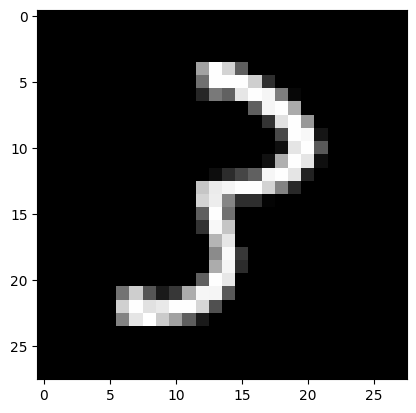

Predicted: 3
Actual: 3


In [16]:
index = 10

plt.imshow(X_test[index].reshape(28,28), cmap="gray")
plt.show()

print("Predicted:", predictions[index])
print("Actual:", true_labels[index])